# Banknote Counterfeit Detection

**Goal:** build a machine learning model able to distinguish genuine banknotes from counterfeit banknotes using geometric measurements.

This notebook follows a portfolio-ready data science workflow:
1. Data loading and quality checks
2. Exploratory data analysis
3. Statistical testing
4. Principal Component Analysis (PCA)
5. Unsupervised clustering with KMeans
6. Supervised classification with Logistic Regression
7. Model comparison and final recommendation

**Business context:** a public security organization wants to automate the detection of counterfeit banknotes from physical measurements.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mode
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Data loading

The main dataset expected by this notebook is `notes.csv`.

The helper function below looks for the file in common locations so the notebook can be run either from the project root or from a `notebooks/` folder.

In [2]:
def find_file(filename: str) -> Path:
    """Find a data file in common project locations."""
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Place the file in the current directory or in data/."
    )

DATA_PATH = find_file("notes.csv")
notes = pd.read_csv(DATA_PATH)
notes.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.67,103.74,103.70,4.01,2.87,113.29
2,True,171.83,103.76,103.76,4.40,2.88,113.84
3,True,171.80,103.78,103.65,3.73,3.12,113.63
4,True,172.05,103.70,103.75,5.04,2.27,113.55


## 3. Dataset overview

We first inspect the number of rows and columns, data types, and summary statistics.

The dataset contains geometric measurements of banknotes and a target variable named `is_genuine`.

In [3]:
print(f"Number of rows : {notes.shape[0]}")
print(f"Number of columns : {notes.shape[1]}")

notes.info()

Number of rows : 170
Number of columns : 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    170 non-null    bool   
 1   diagonal      170 non-null    float64
 2   height_left   170 non-null    float64
 3   height_right  170 non-null    float64
 4   margin_low    170 non-null    float64
 5   margin_up     170 non-null    float64
 6   length        170 non-null    float64
dtypes: bool(1), float64(6)
memory usage: 8.3 KB


In [4]:
notes.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
is_genuine,170,2,True,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagonal,170.0,NaN,NaN,NaN,171.940588,0.305768,171.04,171.73,171.945,172.1375,173.01
height_left,170.0,NaN,NaN,NaN,104.066353,0.298185,103.23,103.8425,104.055,104.2875,104.86
height_right,170.0,NaN,NaN,NaN,103.928118,0.33098,103.14,103.69,103.95,104.17,104.95
margin_low,170.0,NaN,NaN,NaN,4.612118,0.702103,3.54,4.05,4.45,5.1275,6.28
margin_up,170.0,NaN,NaN,NaN,3.170412,0.236361,2.27,3.0125,3.17,3.33,3.68
length,170.0,NaN,NaN,NaN,112.570412,0.924448,109.97,111.855,112.845,113.2875,113.98


## 4. Data quality checks

Before modeling, we check:
- missing values
- duplicate rows
- number of unique values
- data types

This step helps confirm whether the dataset is ready for analysis.

In [5]:
quality_summary = pd.DataFrame({
    "dtype": notes.dtypes,
    "missing_values": notes.isna().sum(),
    "missing_rate": notes.isna().mean().round(4),
    "unique_values": notes.nunique(),
})

quality_summary

,dtype,missing_values,missing_rate,unique_values
is_genuine,bool,0,0.0,2
diagonal,float64,0,0.0,88
height_left,float64,0,0.0,91
height_right,float64,0,0.0,96
margin_low,float64,0,0.0,123
margin_up,float64,0,0.0,81
length,float64,0,0.0,129


In [6]:
print(f"Number of duplicate rows : {notes.duplicated().sum()}")

Number of duplicate rows : 0


## 5. Genuine vs counterfeit distribution

The target variable `is_genuine` indicates whether a banknote is genuine (`True`) or counterfeit (`False`).

A reasonably balanced target distribution is useful for both classification and clustering analysis.

In [7]:
target_counts = notes["is_genuine"].value_counts().rename(index={True: "Genuine", False: "Counterfeit"})
target_rates = notes["is_genuine"].value_counts(normalize=True).rename(index={True: "Genuine", False: "Counterfeit"})

pd.DataFrame({
    "count": target_counts,
    "rate": target_rates.round(3),
})

,count,rate
Genuine,100,0.588
Counterfeit,70,0.412


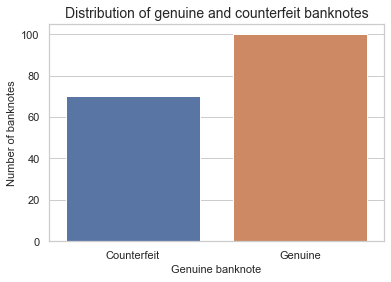

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=notes, x="is_genuine", ax=ax)
ax.set_title("Distribution of genuine and counterfeit banknotes")
ax.set_xlabel("Genuine banknote")
ax.set_ylabel("Number of banknotes")
ax.set_xticklabels(["Counterfeit", "Genuine"])
plt.show()

## 6. Exploratory analysis of numerical variables

We compare the distributions of each measurement between genuine and counterfeit banknotes.

The goal is to identify variables that visually separate the two classes.

In [9]:
TARGET = "is_genuine"
FEATURES = [col for col in notes.columns if col != TARGET]
FEATURES

['diagonal',
 'height_left',
 'height_right',
 'margin_low',
 'margin_up',
 'length']

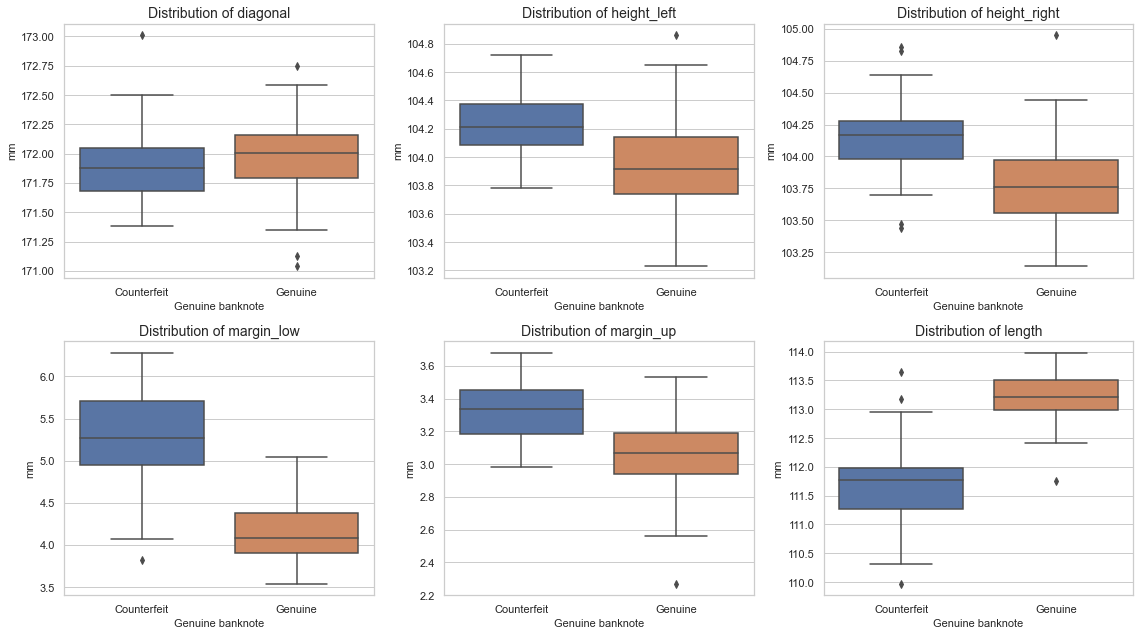

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES):
    sns.boxplot(data=notes, x=TARGET, y=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel("Genuine banknote")
    ax.set_xticklabels(["Counterfeit", "Genuine"])
    ax.set_ylabel("mm")

plt.tight_layout()
plt.show()

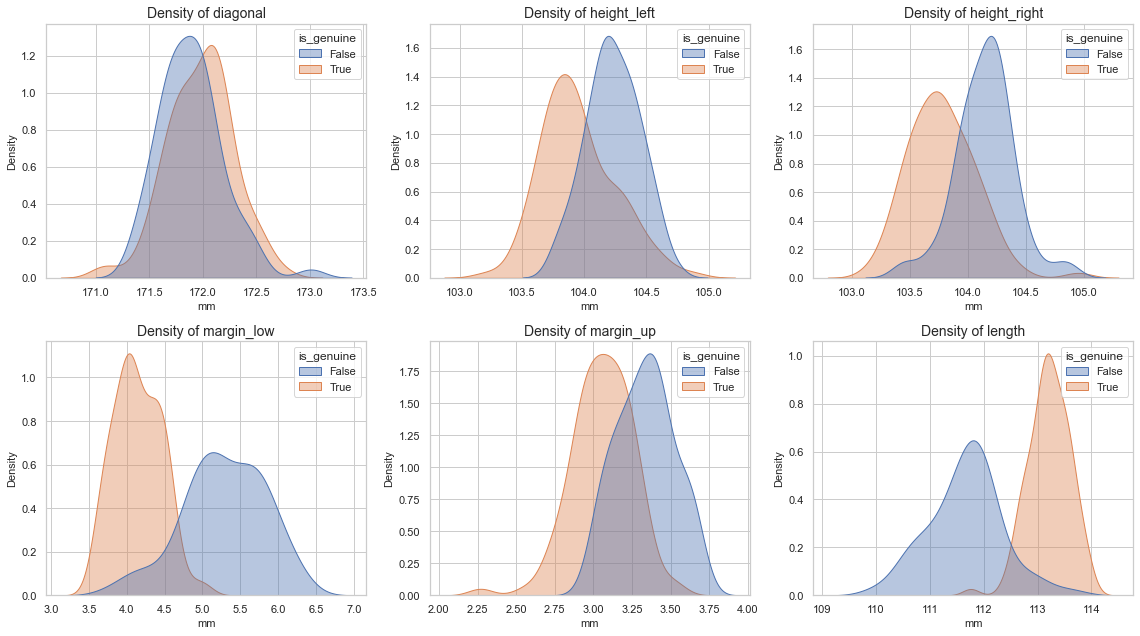

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES):
    sns.kdeplot(data=notes, x=feature, hue=TARGET, fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f"Density of {feature}")
    ax.set_xlabel("mm")

plt.tight_layout()
plt.show()

## 7. Statistical tests on mean differences

For each numerical feature, we run a two-sample t-test comparing genuine and counterfeit banknotes.

If a feature has a statistically significant difference in mean between the two groups, it may be useful for counterfeit detection.

In [12]:
rows = []
true_notes = notes[notes[TARGET] == True]
fake_notes = notes[notes[TARGET] == False]

for feature in FEATURES:
    stat, p_value = stats.ttest_ind(true_notes[feature], fake_notes[feature], equal_var=False)
    rows.append({
        "feature": feature,
        "mean_true": true_notes[feature].mean(),
        "mean_false": fake_notes[feature].mean(),
        "mean_difference": true_notes[feature].mean() - fake_notes[feature].mean(),
        "t_statistic": stat,
        "p_value": p_value,
        "significant_5pct": p_value < 0.05,
    })

ttest_results = pd.DataFrame(rows).sort_values("p_value")
ttest_results

,feature,mean_true,mean_false,mean_difference,t_statistic,p_value,significant_5pct
5,length,113.2072,111.660714,1.546486,17.296894,9.405204e-32,True
3,margin_low,4.1435,5.281571,-1.138071,-15.831084,3.511498e-29,True
4,margin_up,3.0555,3.334571,-0.279071,-9.405217,6.811238e-17,True
2,height_right,103.7759,104.145571,-0.369671,-8.785467,2.252842e-15,True
1,height_left,103.9515,104.230429,-0.278929,-7.138967,2.708399e-11,True
0,diagonal,171.9761,171.889857,0.086243,1.833598,6.867185e-02,False


## 8. Correlations between numerical variables

We inspect the Pearson correlation matrix to understand relationships between measurements and to identify potential redundancy between variables.

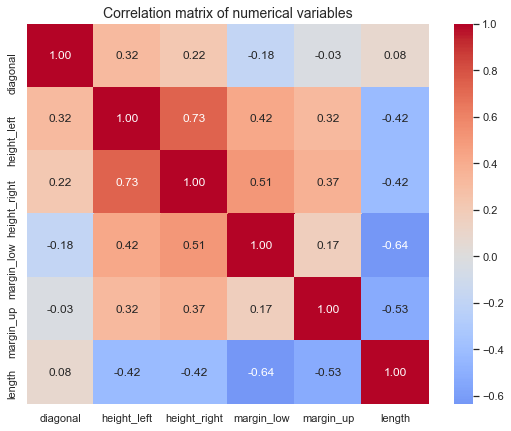

In [13]:
correlation_matrix = notes[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix of numerical variables")
plt.show()

## 9. Principal Component Analysis (PCA)

PCA is used to reduce dimensionality and visualize the structure of the dataset.

Before PCA, the numerical features are standardized because they may have different scales.

In [14]:
X = notes[FEATURES]
y = notes[TARGET].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(FEATURES))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.474479,0.474479
1,PC2,0.219571,0.694050
2,PC3,0.142345,0.836396
3,PC4,0.085263,0.921658
4,PC5,0.046128,0.967787
5,PC6,0.032213,1.000000


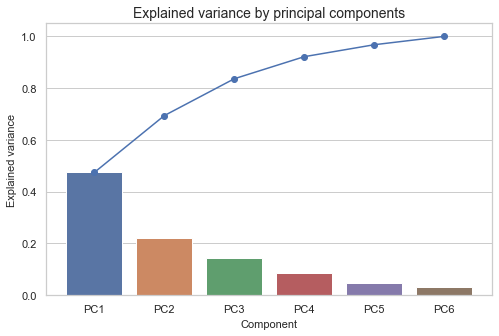

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=explained_variance, x="component", y="explained_variance_ratio", ax=ax)
ax.plot(explained_variance.index, explained_variance["cumulative_variance"], marker="o")
ax.set_title("Explained variance by principal components")
ax.set_xlabel("Component")
ax.set_ylabel("Explained variance")
plt.show()

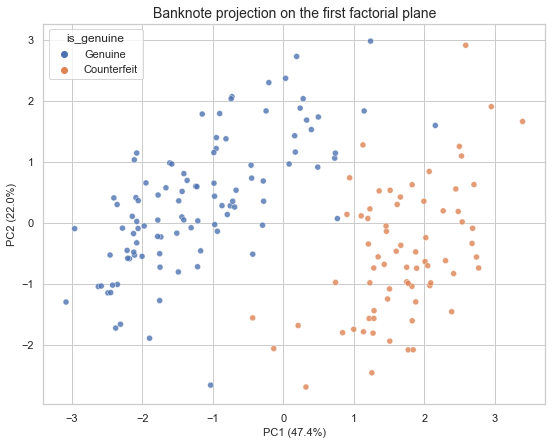

In [16]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df[TARGET] = notes[TARGET].map({True: "Genuine", False: "Counterfeit"})

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET, alpha=0.8, ax=ax)
ax.set_title("Banknote projection on the first factorial plane")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.show()

In [17]:
# Feature loadings on the first two principal components
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=["PC1", "PC2"],
    index=FEATURES,
)

loadings

,PC1,PC2
diagonal,0.073275,0.779639
height_left,0.475502,0.339250
height_right,0.491821,0.235543
margin_low,0.431027,-0.320537
margin_up,0.352540,-0.141120
length,-0.465373,0.314536


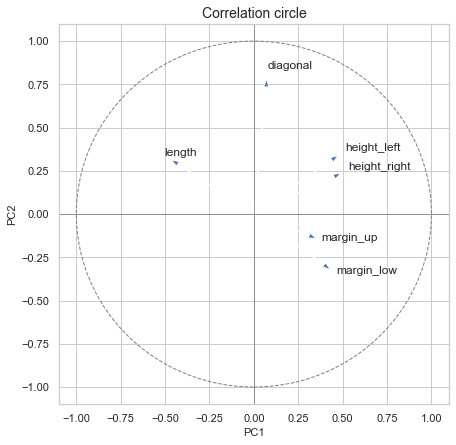

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))

for feature in FEATURES:
    ax.arrow(0, 0, loadings.loc[feature, "PC1"], loadings.loc[feature, "PC2"],
             head_width=0.03, length_includes_head=True)
    ax.text(loadings.loc[feature, "PC1"] * 1.08,
            loadings.loc[feature, "PC2"] * 1.08,
            feature)

circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
ax.add_artist(circle)
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_title("Correlation circle")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

## 10. Unsupervised classification with KMeans

KMeans is used as an unsupervised approach to split the banknotes into two clusters.

Since KMeans cluster labels are arbitrary, we map each cluster to the majority true class before evaluating performance.

In [19]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# KMeans labels are arbitrary. We map them to the majority true class.
cluster_mapping = {}
for cluster_id in np.unique(clusters):
    majority_class = y[clusters == cluster_id].mode()[0]
    cluster_mapping[cluster_id] = majority_class

kmeans_pred = pd.Series(clusters).map(cluster_mapping).astype(int)

kmeans_accuracy = accuracy_score(y, kmeans_pred)
kmeans_precision = precision_score(y, kmeans_pred)
kmeans_recall = recall_score(y, kmeans_pred)
kmeans_f1 = f1_score(y, kmeans_pred)

pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "score": [kmeans_accuracy, kmeans_precision, kmeans_recall, kmeans_f1],
})

,metric,score
0,accuracy,0.947059
1,precision,0.989247
2,recall,0.920000
3,f1_score,0.953368


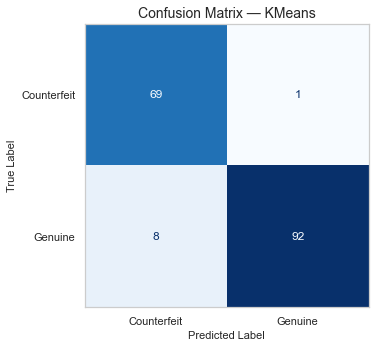

In [20]:
# 🔧 Fix KMeans labels (important)
labels = np.zeros_like(kmeans_pred)

for i in range(2):
    mask = (kmeans_pred == i)
    labels[mask] = mode(y[mask])[0]

kmeans_pred_fixed = labels

# 🎨 Plot propre
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    kmeans_pred_fixed,
    display_labels=["Counterfeit", "Genuine"],
    cmap="Blues",          # 🔥 changement de couleur
    colorbar=False,
    ax=ax
)

ax.set_title("Confusion Matrix — KMeans", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.grid(False)
plt.tight_layout()
plt.show()

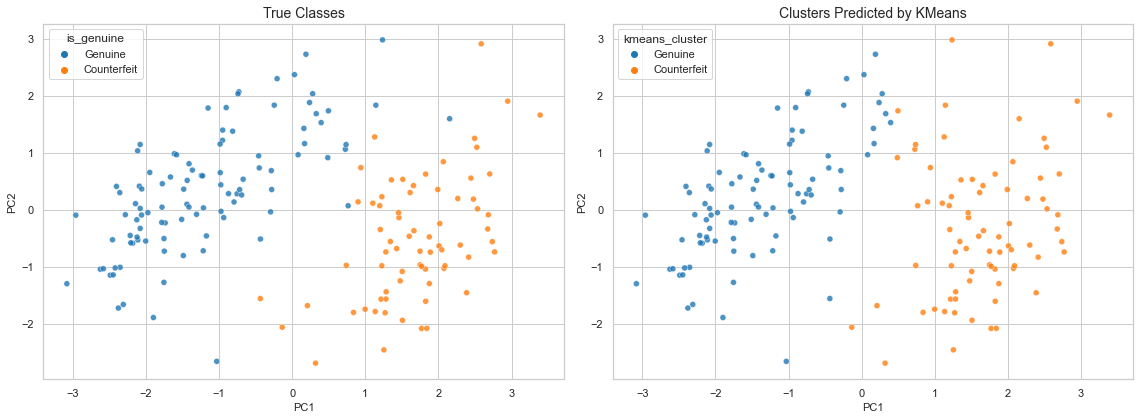

In [22]:
palette = {
    "Genuine": "#1f77b4",       # blue
    "Counterfeit": "#ff7f0e"    # orange
}

pca_df["kmeans_cluster"] = kmeans_pred.map({
    1: "Genuine",
    0: "Counterfeit"
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=TARGET,
    hue_order=["Genuine", "Counterfeit"],
    palette=palette,
    ax=axes[0],
    alpha=0.8
)
axes[0].set_title("True Classes")

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    hue_order=["Genuine", "Counterfeit"],
    palette=palette,
    ax=axes[1],
    alpha=0.8
)
axes[1].set_title("Clusters Predicted by KMeans")

plt.tight_layout()
plt.show()

## 11. Supervised modeling with Logistic Regression

Logistic Regression is trained to predict whether a banknote is genuine.

The model is evaluated on both the training set and a holdout test set.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

log_reg_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
])

log_reg_pipeline.fit(X_train, y_train)

y_train_pred = log_reg_pipeline.predict(X_train)
y_test_pred = log_reg_pipeline.predict(X_test)

metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    "precision": [precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)],
    "recall": [recall_score(y_train, y_train_pred), recall_score(y_test, y_test_pred)],
    "f1_score": [f1_score(y_train, y_train_pred), f1_score(y_test, y_test_pred)],
})

metrics

,dataset,accuracy,precision,recall,f1_score
0,train,0.992647,1.0,0.9875,0.993711
1,test,1.000000,1.0,1.0000,1.000000


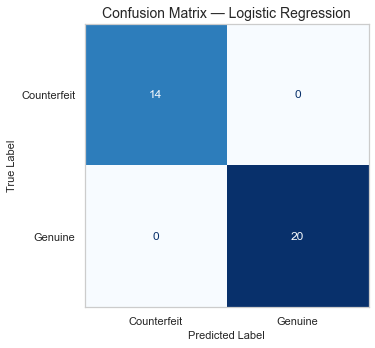

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 🎨 Plot propre
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Counterfeit", "Genuine"],
    cmap="Blues",        # 🔥 couleurs propres
    colorbar=False,
    ax=ax
)

ax.set_title("Confusion Matrix — Logistic Regression", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.grid(False)
plt.tight_layout()
plt.show()


In [26]:
print(classification_report(y_test, y_test_pred, target_names=["Counterfeit", "Genuine"]))

              precision    recall  f1-score   support

 Counterfeit       1.00      1.00      1.00        14
     Genuine       1.00      1.00      1.00        20

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## 12. Cross-validation

Cross-validation provides a more robust estimate of model performance than a single train/test split.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring="accuracy")

print(f"Mean CV accuracy : {cv_scores.mean():.3f}")
print(f"CV standard deviation : {cv_scores.std():.3f}")
print(f"Scores by fold : {np.round(cv_scores, 3)}")

Mean CV accuracy : 0.994
CV standard deviation : 0.012
Scores by fold : [1.    1.    1.    1.    0.971]


## 13. Coefficient interpretation

Because features are standardized in the pipeline, logistic regression coefficients can be compared to understand which variables have the strongest influence on the prediction.

In [28]:
model = log_reg_pipeline.named_steps["model"]
coefficients = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": model.coef_[0],
    "absolute_coefficient": np.abs(model.coef_[0]),
}).sort_values("absolute_coefficient", ascending=False)

coefficients

,feature,coefficient,absolute_coefficient
3,margin_low,-2.289798,2.289798
5,length,1.583903,1.583903
4,margin_up,-1.412125,1.412125
2,height_right,-0.410384,0.410384
0,diagonal,0.306500,0.306500
1,height_left,-0.160550,0.160550


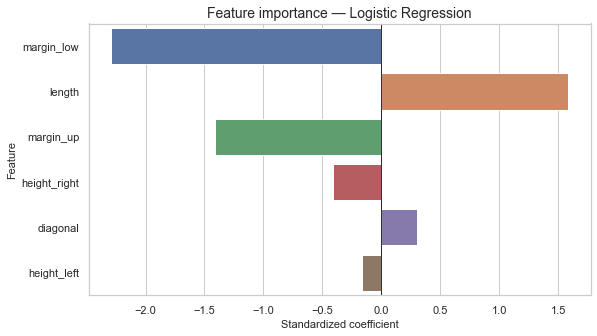

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=coefficients, x="coefficient", y="feature", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature importance — Logistic Regression")
ax.set_xlabel("Standardized coefficient")
ax.set_ylabel("Feature")
plt.show()

## 14. Optimized model using the most influential variables

We build a simplified Logistic Regression model using only the top 3 most influential variables.

This makes the model easier to interpret while keeping strong predictive performance.

In [30]:
TOP_FEATURES = coefficients.head(3)["feature"].tolist()
TOP_FEATURES

['margin_low', 'length', 'margin_up']

In [31]:
X_top = notes[TOP_FEATURES]

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

optimized_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
])

optimized_pipeline.fit(X_train_top, y_train_top)

y_test_top_pred = optimized_pipeline.predict(X_test_top)

optimized_metrics = pd.DataFrame({
    "model": ["Logistic regression — all features", "Logistic regression — top 3 features"],
    "test_accuracy": [accuracy_score(y_test, y_test_pred), accuracy_score(y_test_top, y_test_top_pred)],
    "test_precision": [precision_score(y_test, y_test_pred), precision_score(y_test_top, y_test_top_pred)],
    "test_recall": [recall_score(y_test, y_test_pred), recall_score(y_test_top, y_test_top_pred)],
    "test_f1_score": [f1_score(y_test, y_test_pred), f1_score(y_test_top, y_test_top_pred)],
})

optimized_metrics

,model,test_accuracy,test_precision,test_recall,test_f1_score
0,Logistic regression — all features,1.0,1.0,1.0,1.0
1,Logistic regression — top 3 features,1.0,1.0,1.0,1.0


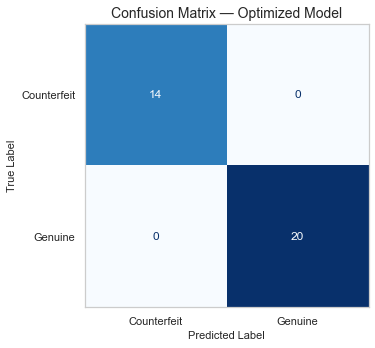

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 🎨 Plot propre
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_top,
    y_test_top_pred,
    display_labels=["Counterfeit", "Genuine"],
    cmap="Blues",        # 🔥 cohérent avec les autres modèles
    colorbar=False,
    ax=ax
)

ax.set_title("Confusion Matrix — Optimized Model", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.grid(False)
plt.tight_layout()
plt.show()

## 15. Final model comparison

We compare KMeans, Logistic Regression with all features, and optimized Logistic Regression.

The objective is to select the best model for counterfeit detection.

In [34]:
comparison = pd.DataFrame({
    "model": ["KMeans", "Logistic regression", "Optimized logistic regression"],
    "approach": ["Unsupervised", "Supervised", "Supervised"],
    "accuracy": [kmeans_accuracy, accuracy_score(y_test, y_test_pred), accuracy_score(y_test_top, y_test_top_pred)],
    "precision": [kmeans_precision, precision_score(y_test, y_test_pred), precision_score(y_test_top, y_test_top_pred)],
    "recall": [kmeans_recall, recall_score(y_test, y_test_pred), recall_score(y_test_top, y_test_top_pred)],
    "f1_score": [kmeans_f1, f1_score(y_test, y_test_pred), f1_score(y_test_top, y_test_top_pred)],
})

comparison

,model,approach,accuracy,precision,recall,f1_score
0,KMeans,Unsupervised,0.947059,0.989247,0.92,0.953368
1,Logistic regression,Supervised,1.000000,1.000000,1.00,1.000000
2,Optimized logistic regression,Supervised,1.000000,1.000000,1.00,1.000000


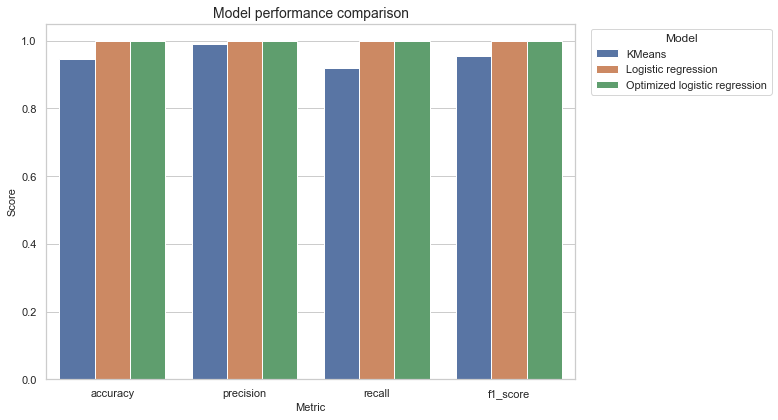

In [35]:
comparison_melted = comparison.melt(
    id_vars=["model", "approach"],
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=comparison_melted, x="metric", y="score", hue="model", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Model performance comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 16. Prediction on new banknotes

If an `example.csv` file is available, the optimized model can generate predictions on new banknotes.

The output includes:
- predicted class
- probability of being genuine

In [36]:
def predict_new_banknotes(file_name: str = "example.csv") -> pd.DataFrame:
    """Predict whether new banknotes are genuine using the optimized model."""
    path = find_file(file_name)
    new_notes = pd.read_csv(path)

    missing_features = set(TOP_FEATURES) - set(new_notes.columns)
    if missing_features:
        raise ValueError(f"Features missing in {file_name}: {missing_features}")

    predictions = optimized_pipeline.predict(new_notes[TOP_FEATURES])
    probabilities = optimized_pipeline.predict_proba(new_notes[TOP_FEATURES])[:, 1]

    results = new_notes.copy()
    results["predicted_is_genuine"] = predictions.astype(bool)
    results["probability_genuine"] = probabilities.round(4)

    return results

try:
    prediction_results = predict_new_banknotes("example.csv")
    display(prediction_results.head())
except FileNotFoundError:
    print("No example.csv file found. Place it in data/ to generate predictions.")

,diagonal,height_left,height_right,margin_low,margin_up,length,id,predicted_is_genuine,probability_genuine
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,False,0.0134
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,False,0.0026
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,False,0.0223
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,True,0.9656
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,True,0.9944


## 17. Conclusion

The supervised Logistic Regression model is better suited for counterfeit detection than the unsupervised KMeans approach.

The optimized Logistic Regression model is recommended because it keeps strong performance while relying on fewer, interpretable features.